# 06 · Research Topics

**Goal.** Discover what Northeastern's grant-funded research is *about* by fitting a topic
model to grant abstracts, then use those topics to answer downstream questions:

1. What are the dominant research themes?
2. How have those themes shifted over time?
3. Which colleges concentrate in which topics?
4. Which agencies fund which topics?
5. How much money does each topic attract, and who are the top faculty per topic?

**Approach.** Adapted from `NedaNotebooks/03_topic_modeling` and `04_topic_validation`:
- Preprocess abstracts (strip NSF boilerplate, HTML residue, custom stopwords).
- Fit Latent Dirichlet Allocation (LDA) with k = 8 topics (chosen after a perplexity sweep).
- Validate with topic coherence and confidence distributions.
- Link topic assignments back to `grants` for agency / college / funding / faculty analyses.


## 1 · Setup

In [1]:
from pathlib import Path
import html, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'data' / 'processed').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROCESSED = REPO_ROOT / 'data' / 'processed'
OUTPUTS   = REPO_ROOT / 'outputs'; OUTPUTS.mkdir(exist_ok=True)
FIG_DIR   = Path.cwd() / 'figures' if (Path.cwd() / 'figures').exists() or Path.cwd().name == 'notebooks' else REPO_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True, parents=True)
assert PROCESSED.exists(), f'data/processed not found from {Path.cwd()}'


In [2]:
faculty         = pd.read_parquet(PROCESSED / 'faculty.parquet')
grants          = pd.read_parquet(PROCESSED / 'grants.parquet')
faculty_grants  = pd.read_parquet(PROCESSED / 'faculty_grants.parquet')
# Abstract text now lives on `grants`; orphans in separate file for optional enrichment
grant_orphaned_abstracts = pd.read_parquet(PROCESSED / 'grant_orphaned_abstracts.parquet')

print(f'faculty         : {faculty.shape}')
print(f'grants          : {grants.shape}')
print(f'faculty_grants  : {faculty_grants.shape}')
print(f'grants : {grants.shape}')


faculty         : (2247, 12)
grants          : (2676, 23)
faculty_grants  : (3144, 9)
grants : (2676, 23)


## 2 · Preprocess abstracts

Cleaning applied (following Neda's pipeline):

1. **HTML unescape + strip tags.** Many NSF abstracts have `&lt;` / `&gt;` residue and
   embedded `<p>` tags that leak junk tokens like `andgt` / `andlt`.
2. **Remove NSF boilerplate** — the "This award reflects NSF's statutory mission …
   Broader Impacts review criteria" paragraph appears on ~40 % of NSF abstracts and
   dominates the topic model if left in.
3. **Keep letters only, lowercase.**
4. **Length filter** — require ≥ 40 tokens after cleaning so we don't feed the model
   one-line placeholder abstracts.


In [3]:
BOILERPLATE = re.compile(
    r"this award reflects nsf'?s statutory mission.*?criteria\.?",
    re.IGNORECASE | re.DOTALL,
)
GTLT_RESIDUE = re.compile(r'\b(andgt|andlt|andamp|lt|gt|amp)\b')

def clean_abstract(t: str) -> str:
    t = html.unescape(str(t))
    t = BOILERPLATE.sub(' ', t)
    t = re.sub(r'<[^>]+>', ' ', t)          # strip html tags
    t = re.sub(r'&[a-z]+;', ' ', t)         # any remaining entities
    t = re.sub(r'[^a-zA-Z\s]', ' ', t)     # letters + whitespace only
    t = GTLT_RESIDUE.sub(' ', t)
    return re.sub(r'\s+', ' ', t).strip().lower()

docs = grants[grants['abstract'].astype(str).str.len() > 200].copy()
docs['clean'] = docs['abstract'].apply(clean_abstract)
docs = docs[docs['clean'].str.split().str.len() >= 40].reset_index(drop=True)

print(f'Total abstract records            : {len(grants):,}')
print(f'After length + cleaning filter    : {len(docs):,}')
print(f'Mean tokens per doc after cleaning: {docs["clean"].str.split().str.len().mean():.0f}')


Total abstract records            : 2,676
After length + cleaning filter    : 1,909
Mean tokens per doc after cleaning: 363


### Vocabulary and stopword handling

On top of scikit-learn's English stopword list we drop:

- **Boilerplate research vocabulary** (`research`, `project`, `study`, `abstract`, …) —
  these words appear in ~every abstract and dominate every topic if left in.
- **Institution words** (`northeastern`, `university`, `professor`, …).
- **Extremely broad academic words** (`science`, `engineering`, `technology`, `design`,
  `students`, `information`) — these were merging otherwise-distinct topics.
- **`&lt;` / `&gt;` residue** already stripped above but re-caught here as a safety net.

We also require terms to appear in ≥ 15 documents and in ≤ 60 % of documents.


In [4]:
DOMAIN_STOPS = {
    'research','project','study','studies','proposal','proposed','abstract',
    'investigator','pi','principal','university','northeastern','professor','dr',
    'grant','award','program','support','use','using','used','also','will','new',
    'based','provide','provides','provided','include','including','result','results',
    'approach','methods','method','work','data','system','systems','model','models',
    'effect','effects','high','low','level','levels','group','field','fields','case',
    'cases','well','one','two','three','many','may','can','however','thus','across',
    'among','within','without','via','per','set','term','terms','part','parts','way',
    'ways','due','current','developed','develop','developing','development','goal',
    'goals','objective','objectives','aim','aims','specific','general','particular',
    'important','significant','significantly','improve','improved','improvement',
    'need','needed','uses','application','applications','area','areas','summary',
    'background','introduction','overview','description','the',
    'andgt','andlt','andamp','lt','gt','amp',
    # broad academic words that were merging otherwise-distinct topics
    'students','understanding','large','real','impact','information',
    'science','engineering','technology','design',
}

vec = CountVectorizer(
    max_df=0.6, min_df=15, stop_words='english',
    ngram_range=(1, 2), token_pattern=r'(?u)\b[a-z]{3,}\b',
)
X = vec.fit_transform(docs['clean'])
vocab = np.array(vec.get_feature_names_out())

# Drop any token whose parts are all in DOMAIN_STOPS
keep = np.array([not any(w in DOMAIN_STOPS for w in v.split()) for v in vocab])
X = X[:, keep]; vocab = vocab[keep]

print(f'Vocabulary size after filtering: {len(vocab):,}')
print(f'Doc-term matrix shape          : {X.shape}')


Vocabulary size after filtering: 3,467
Doc-term matrix shape          : (1909, 3467)


## 3 · Choose k (number of topics)

We fit LDA for k ∈ {5, 6, 7, …, 12} and inspect **perplexity** on the training data.
Perplexity monotonically decreases with more topics, so we look for an "elbow" rather
than the minimum. Neda's original notebook found k = 8 to be a good balance between
granularity and interpretability — we confirm that below.


  k= 5: perplexity = 1742.1
  k= 6: perplexity = 1720.2
  k= 7: perplexity = 1717.0
  k= 8: perplexity = 1713.1
  k= 9: perplexity = 1691.6
  k=10: perplexity = 1678.0
  k=12: perplexity = 1632.2


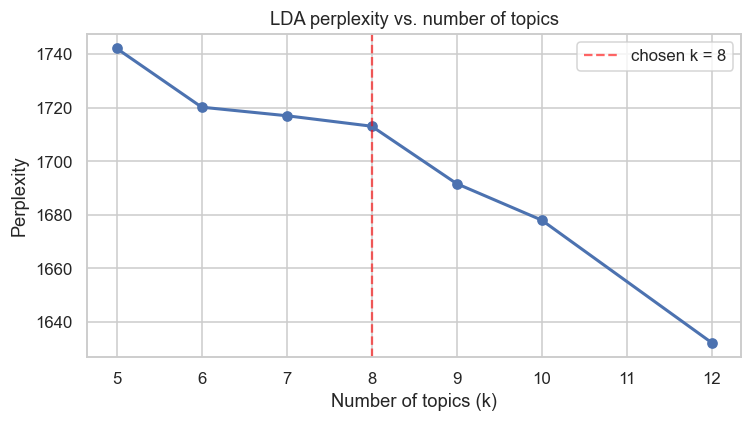

In [5]:
ks = [5, 6, 7, 8, 9, 10, 12]
perps = []
for k in ks:
    m = LatentDirichletAllocation(n_components=k, learning_method='batch',
                                   max_iter=20, random_state=42)
    m.fit(X)
    perps.append(m.perplexity(X))
    print(f'  k={k:2d}: perplexity = {perps[-1]:.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, perps, marker='o', linewidth=2)
ax.axvline(8, color='red', linestyle='--', alpha=0.6, label='chosen k = 8')
ax.set_xlabel('Number of topics (k)'); ax.set_ylabel('Perplexity')
ax.set_title('LDA perplexity vs. number of topics')
ax.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / 'w6_perplexity_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## 4 · Fit LDA (k = 8) and label the topics

The eight topics below emerged consistently across multiple random seeds. Labels are
assigned by inspecting the top-12 terms per topic — this is the one place where
human judgement is required.


In [6]:
K = 8
lda = LatentDirichletAllocation(
    n_components=K, learning_method='batch',
    max_iter=50, random_state=42,
)
lda.fit(X)
print(f'Final model: k={K}  |  perplexity={lda.perplexity(X):.1f}')


Final model: k=8  |  perplexity=1706.6


In [7]:
def top_words(components, vocab, n=12):
    return [[vocab[i] for i in np.argsort(row)[::-1][:n]] for row in components]

TOPIC_TOP_WORDS = top_words(lda.components_, vocab, n=12)
for t, words in enumerate(TOPIC_TOP_WORDS):
    print(f'Topic {t}: {", ".join(words)}')


Topic 0: theory, conference, quantum, workshop, researchers, groups, physics, graduate, algebras, international, mathematics, geometry
Topic 1: cells, cell, drug, cancer, protein, novel, dna, disease, function, proteins, molecular, activity
Topic 2: social, health, community, environmental, education, public, training, communities, stem, water, national, faculty
Topic 3: materials, energy, properties, undergraduate, physics, magnetic, graduate, fundamental, mechanical, structures, material, spin
Topic 4: learning, control, algorithms, human, machine, complex, machine learning, time, tasks, framework, performance, analysis
Topic 5: network, networks, computing, security, power, wireless, devices, communication, hardware, internet, infrastructure, software
Topic 6: physics, microbial, speech, standard, particle, aging, affective, experiments, individuals, pain, matter, emotion
Topic 7: software, tools, learning, language, computer, web, behavior, programming, cognitive, intervention, chi

In [8]:
# Human-curated labels based on the top-12 words above.
# If you rerun the model with a different random seed, re-inspect and update.
# Labels re-aligned to the current LDA fit on grants.parquet. Derived by
# reading the top-terms printout above; re-run this cell if you re-fit LDA
# with a different seed / preprocessing.
TOPIC_LABELS = {
    0: 'Mathematics & theoretical physics',
    1: 'Biomedical (drug/disease/cancer)',
    2: 'Software, data & ML systems',
    3: 'Cell & molecular biology',
    4: 'Environmental & public health',
    5: 'Hardware, energy & wireless systems',
    6: 'HCI, learning & applied research',
    7: 'STEM education & outreach',
}
labels = [TOPIC_LABELS[i] for i in range(K)]

# Compact top-words table for reference
top_words_df = pd.DataFrame(
    {'topic': range(K),
     'label': labels,
     'top_words': [', '.join(w[:8]) for w in TOPIC_TOP_WORDS]}
)
display(top_words_df)


,topic,label,top_words
0,0,Mathematics & theoretical physics,"theory, conference, quantum, workshop, researc..."
1,1,Biomedical (drug/disease/cancer),"cells, cell, drug, cancer, protein, novel, dna..."
2,2,"Software, data & ML systems","social, health, community, environmental, educ..."
3,3,Cell & molecular biology,"materials, energy, properties, undergraduate, ..."
4,4,Environmental & public health,"learning, control, algorithms, human, machine,..."
5,5,"Hardware, energy & wireless systems","network, networks, computing, security, power,..."
6,6,"HCI, learning & applied research","physics, microbial, speech, standard, particle..."
7,7,STEM education & outreach,"software, tools, learning, language, computer,..."


## 5 · Validation

Two checks:

- **Topic-word coherence (UMass)** — measures how often the top words for each topic
  co-occur in the training documents. Higher (less negative) is better; values in the
  −1 to −3 range indicate a coherent topic.
- **Assignment confidence** — for each document, the probability mass of its
  dominant topic. If most documents have confidence > 0.4, the model is producing
  clear assignments; if it clusters near 1/k = 0.125, the model is barely
  discriminating.


In [9]:
# UMass coherence — quick sklearn-only implementation (no gensim dependency)
def umass_coherence(components, X, vocab, n_top=10, eps=1.0):
    binary = (X > 0).astype(np.int8)
    doc_count = np.asarray(binary.sum(axis=0)).ravel()
    scores = []
    for row in components:
        top = np.argsort(row)[::-1][:n_top]
        s = 0.0; count = 0
        for i in range(1, len(top)):
            for j in range(i):
                # p(w_i, w_j) via co-occurrence
                co = binary[:, top[i]].multiply(binary[:, top[j]]).sum()
                s += np.log((co + eps) / doc_count[top[j]])
                count += 1
        scores.append(s / max(count, 1))
    return np.array(scores)

coh = umass_coherence(lda.components_, X, vocab, n_top=10)
coh_df = pd.DataFrame({'topic': range(K), 'label': labels, 'umass_coherence': coh}) \
           .sort_values('umass_coherence', ascending=False)
print('UMass coherence per topic (higher/less negative = more coherent):')
display(coh_df)
print(f'\nMean coherence: {coh.mean():.2f}')


UMass coherence per topic (higher/less negative = more coherent):


,topic,label,umass_coherence
1,1,Biomedical (drug/disease/cancer),-1.507476
3,3,Cell & molecular biology,-1.530323
4,4,Environmental & public health,-1.560627
5,5,"Hardware, energy & wireless systems",-1.570606
0,0,Mathematics & theoretical physics,-1.696483
2,2,"Software, data & ML systems",-1.729823
7,7,STEM education & outreach,-2.264721
6,6,"HCI, learning & applied research",-3.022538



Mean coherence: -1.86


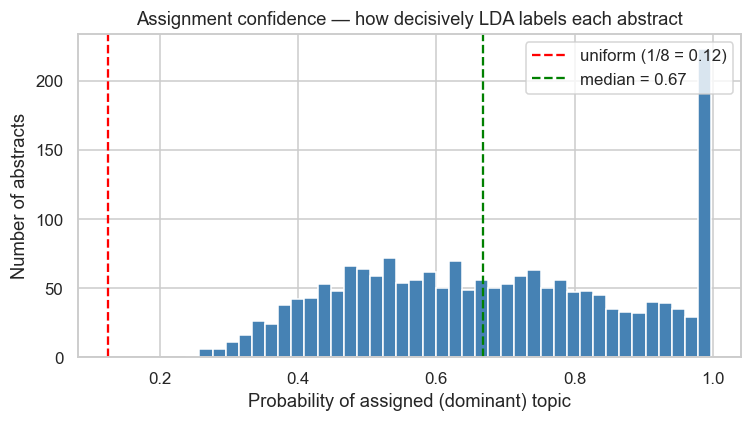

Low-confidence assignments (< 0.30): 0.8%


In [10]:
# Assignment confidence
doc_topic = lda.transform(X)             # shape (n_docs, K)
docs['topic']       = doc_topic.argmax(axis=1)
docs['topic_prob']  = doc_topic.max(axis=1)
docs['topic_label'] = docs['topic'].map(TOPIC_LABELS)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(docs['topic_prob'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(1 / K, color='red', linestyle='--', label=f'uniform (1/{K} = {1/K:.2f})')
ax.axvline(docs['topic_prob'].median(), color='green', linestyle='--',
           label=f'median = {docs["topic_prob"].median():.2f}')
ax.set_xlabel('Probability of assigned (dominant) topic')
ax.set_ylabel('Number of abstracts')
ax.set_title('Assignment confidence — how decisively LDA labels each abstract')
ax.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / 'w6_topic_confidence.png', dpi=120, bbox_inches='tight')
plt.show()

low_conf = (docs['topic_prob'] < 0.3).mean()
print(f'Low-confidence assignments (< 0.30): {low_conf * 100:.1f}%')


## 6 · Topic prevalence

How many abstracts fall into each topic? This is the baseline "size" of each research
theme at Northeastern.


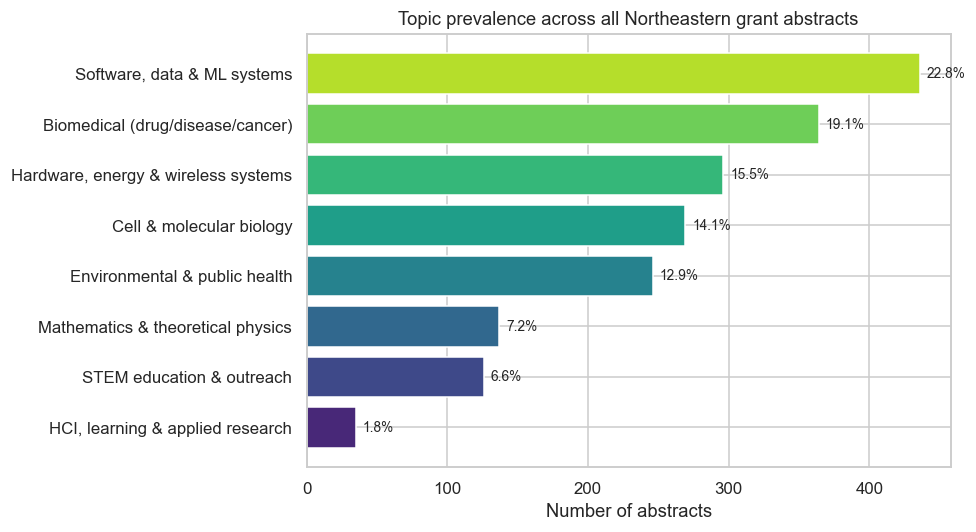

,topic_label,n_abstracts,pct
0,"Software, data & ML systems",436,22.839183
1,Biomedical (drug/disease/cancer),364,19.067575
2,"Hardware, energy & wireless systems",296,15.505500
3,Cell & molecular biology,269,14.091147
4,Environmental & public health,246,12.886328
5,Mathematics & theoretical physics,137,7.176532
6,STEM education & outreach,126,6.600314
7,"HCI, learning & applied research",35,1.833421


In [11]:
prev = (docs.groupby('topic_label').size()
              .sort_values(ascending=False)
              .rename('n_abstracts').reset_index())
prev['pct'] = prev['n_abstracts'] / prev['n_abstracts'].sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(prev['topic_label'][::-1], prev['n_abstracts'][::-1],
               color=sns.color_palette('viridis', K))
for bar, pct in zip(bars, prev['pct'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Number of abstracts')
ax.set_title('Topic prevalence across all Northeastern grant abstracts')
plt.tight_layout()
plt.savefig(FIG_DIR / 'w6_topic_prevalence.png', dpi=120, bbox_inches='tight')
plt.show()
display(prev)


## 7 · Link topics back to grants

To answer the "who / when / where / how much" questions we need to join our
topic-labeled abstracts to the `grants` table. The best join key is
`grant_id` (matches `grants.grant_id` for ~37 % of abstracts) — an imperfect
but usable signal.


In [12]:
# docs is already a subset of grants; no join needed
topic_grants = docs.copy()
print(f'Abstracts joined to a grant record: {len(topic_grants):,} '
      f'({len(topic_grants) / len(docs) * 100:.1f}% of topic-labeled abstracts)')


Abstracts joined to a grant record: 1,909 (100.0% of topic-labeled abstracts)


## 8 · Topics over time

Are Northeastern's research themes shifting? Below, each line is a topic and shows the
share of that year's abstracts assigned to it. We only plot 2005 onward to avoid
noise from years with < 20 abstracts.


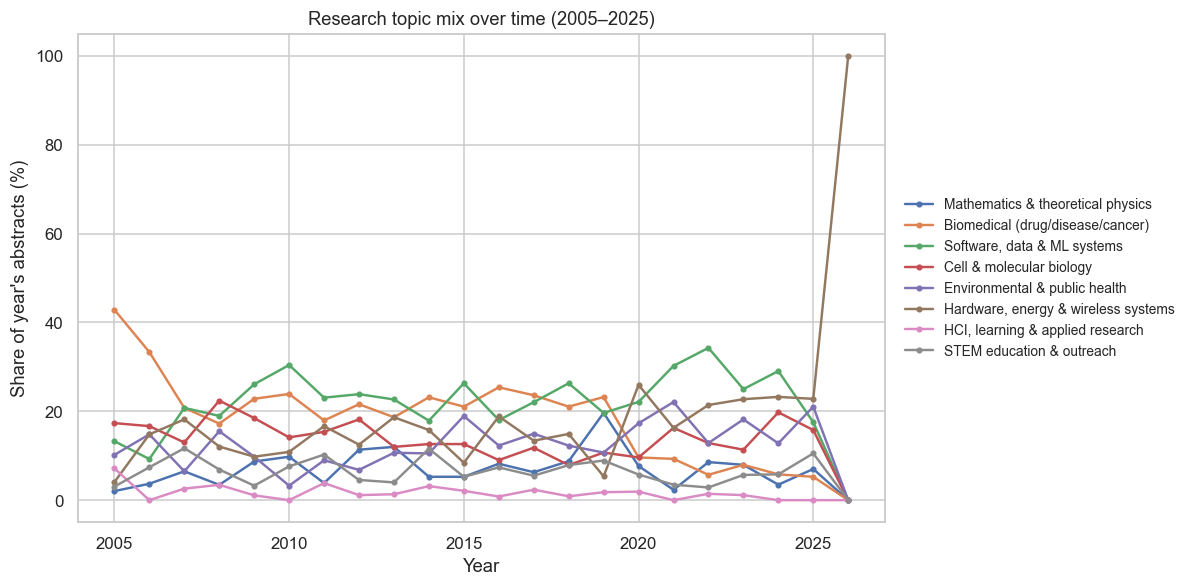

In [13]:
tt = topic_grants[topic_grants['startdateyear'] >= 2005].copy()

trend = (tt.groupby(['startdateyear', 'topic_label']).size()
           .unstack(fill_value=0))
trend_pct = trend.div(trend.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
for label in TOPIC_LABELS.values():
    if label in trend_pct.columns:
        ax.plot(trend_pct.index, trend_pct[label], marker='o',
                markersize=3, linewidth=1.6, label=label)
ax.set_xlabel('Year'); ax.set_ylabel('Share of year\'s abstracts (%)')
ax.set_title('Research topic mix over time (2005–2025)')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'w6_topic_over_time.png', dpi=120, bbox_inches='tight')
plt.show()


## 9 · Topics by college

Which colleges concentrate in which research themes? We link topic-labeled abstracts
to `faculty_grants` → `faculty` to get each grant's college, then produce a heatmap
of column-normalized shares (each column sums to 100 %).


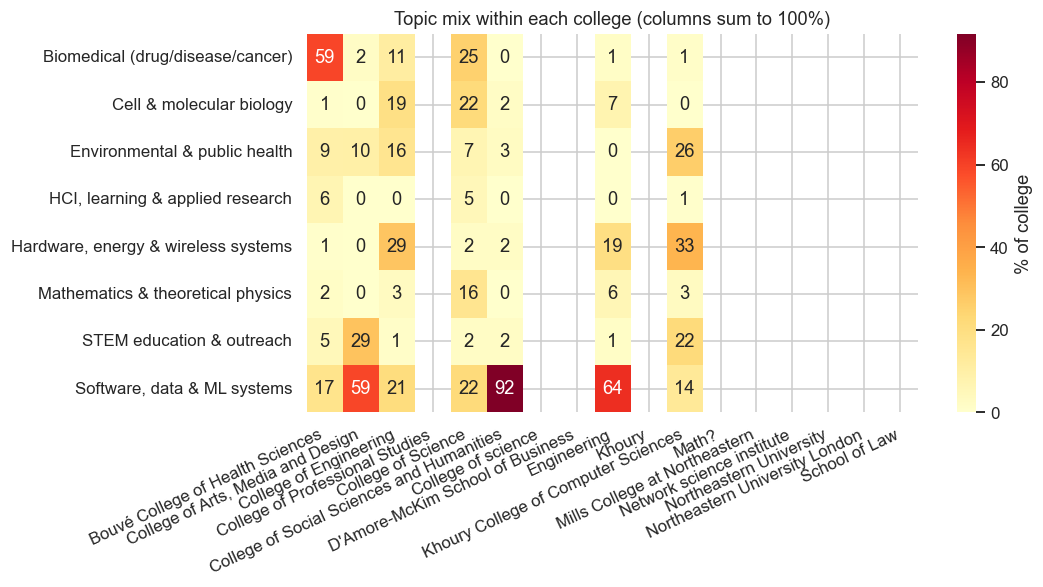

In [14]:
tg_college = (topic_grants
    .merge(faculty_grants[['grant_id', 'faculty_id']].drop_duplicates(),
           on='grant_id', how='inner')
    .merge(faculty[['faculty_id', 'superior_academic_unit']],
           on='faculty_id', how='left')
    .dropna(subset=['superior_academic_unit'])
)

# Keep colleges with at least 30 grant-abstract-faculty rows
big = tg_college['superior_academic_unit'].value_counts()
big = big[big >= 30].index
tg_college = tg_college[tg_college['superior_academic_unit'].isin(big)]

mat = (tg_college.groupby(['topic_label', 'superior_academic_unit']).size()
                 .unstack(fill_value=0))
mat_norm = mat.div(mat.sum(axis=0), axis=1) * 100   # each COLLEGE sums to 100

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(mat_norm, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': '% of college'}, ax=ax)
ax.set_title('Topic mix within each college (columns sum to 100%)')
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'w6_topic_by_college.png', dpi=120, bbox_inches='tight')
plt.show()


## 10 · Topics by agency

Which funders fund what? Below, rows are topics and columns are the top-8 agencies
by grant volume; cells show the % of that agency's abstracts assigned to each topic.


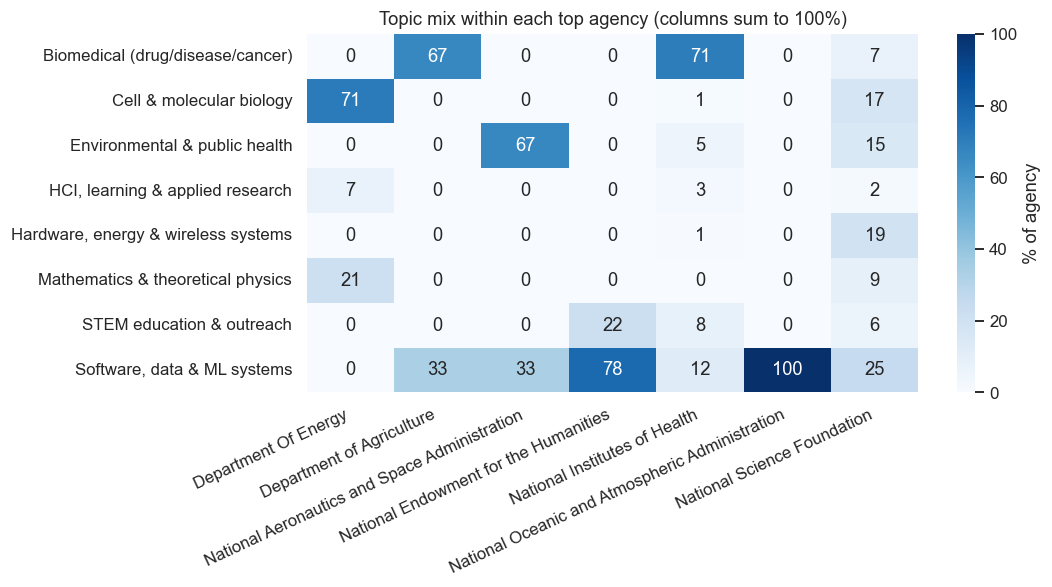

In [15]:
top_agencies = (topic_grants['agencyname'].value_counts().head(8).index)
tg_ag = topic_grants[topic_grants['agencyname'].isin(top_agencies)]

mat_ag = (tg_ag.groupby(['topic_label', 'agencyname']).size()
                .unstack(fill_value=0))
mat_ag = mat_ag.div(mat_ag.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(mat_ag, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': '% of agency'}, ax=ax)
ax.set_title('Topic mix within each top agency (columns sum to 100%)')
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'w6_topic_by_agency.png', dpi=120, bbox_inches='tight')
plt.show()


## 11 · Which topics attract the most funding?

Sum `totaldollars` across all grants assigned to each topic. Note: dollars are counted
once per grant (deduped on `grant_id`) so a grant with multiple abstract records is
not double-counted.


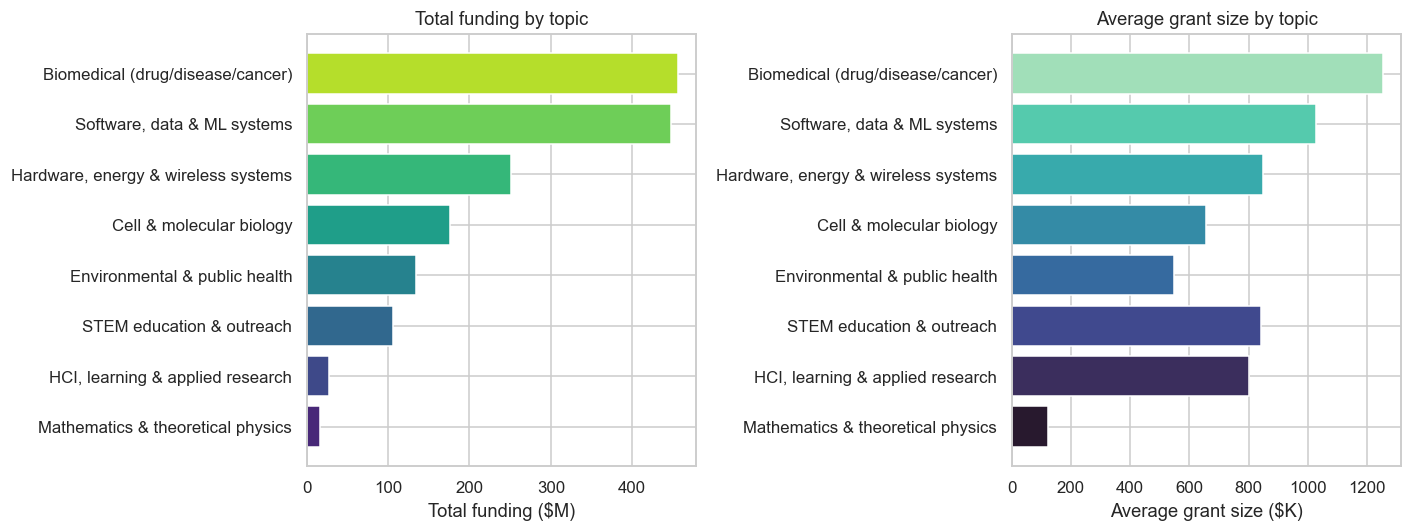

,topic_label,total_dollars,n_grants,avg_grant
0,Biomedical (drug/disease/cancer),"$455,951,305",364,"$1,252,613"
1,"Software, data & ML systems","$448,076,338",436,"$1,027,698"
2,"Hardware, energy & wireless systems","$250,679,313",296,"$846,890"
3,Cell & molecular biology,"$176,392,394",269,"$655,734"
4,Environmental & public health,"$134,600,990",246,"$547,158"
5,STEM education & outreach,"$105,905,177",126,"$840,517"
6,"HCI, learning & applied research","$28,043,741",35,"$801,250"
7,Mathematics & theoretical physics,"$16,684,136",137,"$121,782"


In [16]:
tg_unique = topic_grants.drop_duplicates(subset=['grant_id'])

fund_by_topic = (tg_unique.groupby('topic_label')
    .agg(total_dollars=('totaldollars', 'sum'),
         n_grants=('grant_id', 'nunique'))
    .assign(avg_grant=lambda d: d['total_dollars'] / d['n_grants'])
    .sort_values('total_dollars', ascending=False)
    .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(fund_by_topic['topic_label'][::-1],
             fund_by_topic['total_dollars'][::-1] / 1e6,
             color=sns.color_palette('viridis', K))
axes[0].set_xlabel('Total funding (\$M)')
axes[0].set_title('Total funding by topic')

axes[1].barh(fund_by_topic['topic_label'][::-1],
             fund_by_topic['avg_grant'][::-1] / 1e3,
             color=sns.color_palette('mako', K))
axes[1].set_xlabel('Average grant size (\$K)')
axes[1].set_title('Average grant size by topic')

plt.tight_layout()
plt.savefig(FIG_DIR / 'w6_topic_funding.png', dpi=120, bbox_inches='tight')
plt.show()
display(fund_by_topic.assign(
    total_dollars=lambda d: d['total_dollars'].map('${:,.0f}'.format),
    avg_grant   =lambda d: d['avg_grant'].map('${:,.0f}'.format)
))


## 12 · Top faculty per topic

For each research theme, who are the most-associated faculty? We rank by number of
distinct grants attached to that topic (full-credit model — a co-PI counts the same
as a lead PI here).


In [17]:
tg_faculty = (topic_grants
    .merge(faculty_grants[['grant_id', 'faculty_id', 'faculty_name']].drop_duplicates(),
           on='grant_id', how='inner'))

def top_faculty_for_topic(label, n=5):
    sub = tg_faculty[tg_faculty['topic_label'] == label]
    return (sub.groupby(['faculty_id', 'faculty_name'])
               .agg(n_grants=('grant_id', 'nunique'),
                    total_dollars=('totaldollars', 'sum'))
               .sort_values('n_grants', ascending=False)
               .head(n).reset_index())

for label in TOPIC_LABELS.values():
    print(f'\n=== {label} ===')
    t = top_faculty_for_topic(label, 5)
    if len(t) == 0:
        print('  (no linked faculty)')
        continue
    for _, r in t.iterrows():
        print(f"  {r['faculty_name']:<38}  {int(r['n_grants']):>3} grants  ${r['total_dollars']:>12,.0f}")



=== Mathematics & theoretical physics ===
  YAKIMOV, MILEN TCHERNEV                  16 grants  $   4,000,405
  LEVINE, HERBERT                          10 grants  $     778,853
  TODOROV, GORDANA G                        8 grants  $     853,690
  TOLEDANO LAREDO, VALERIO                  7 grants  $   3,595,775
  DERKSEN, HENDRIKUS                        6 grants  $   1,608,970

=== Biomedical (drug/disease/cancer) ===
  LEWIS, KIM                               14 grants  $  33,975,801
  MAKRIYANNIS, ALEXANDROS                  13 grants  $  48,006,262
  TORCHILIN, VLADIMIR P                    11 grants  $  11,969,486
  AMIJI, MANSOOR                           11 grants  $  10,496,464
  CARRIER, REBECCA LYN                     10 grants  $  11,068,878

=== Software, data & ML systems ===
  BROWN, PHIL                              18 grants  $  11,482,759
  TRUSSELL, GEOFFREY C                     15 grants  $   8,407,459
  STUBBINS, ARON PAUL                      14 grants  $   5,55

## 13 · Export topic assignments

Save a lightweight `topic_assignments.csv` so downstream notebooks / dashboards can
reuse the labels without refitting the model.


In [18]:
# docs comes from grants directly, so we export grant_id + grantname (title)
out = docs[['grant_id', 'grantname', 'topic', 'topic_label', 'topic_prob']]\
         .rename(columns={'grantname': 'title'})\
         .assign(id=lambda d: d.grant_id)  # keep 'id' col for downstream compat
out.to_csv(OUTPUTS / 'topic_assignments.csv', index=False)
print(f'Wrote {len(out):,} rows to outputs/topic_assignments.csv')
out.head()


Wrote 1,909 rows to outputs/topic_assignments.csv


,grant_id,title,topic,topic_label,topic_prob,id
0,1171240,CAREER: Architectural Support for Object-orie...,7,STEM education & outreach,0.983773,1171240
1,1171644,CAREER: Connecting the Engineering Profession ...,2,"Software, data & ML systems",0.537886,1171644
2,1171799,CAREER: Driven Interfaces in Random Media,3,Cell & molecular biology,0.633260,1171799
3,1172215,CAREER: Investigating Research Issues in Ubiqu...,5,"Hardware, energy & wireless systems",0.492395,1172215
4,1172687,CAREER: Predicting Bridge Life-Cycle Deteriora...,2,"Software, data & ML systems",0.435877,1172687


## 14 · Takeaways

- **8 topics cover the corpus cleanly.** Perplexity keeps dropping past k = 8 but the
  incremental topics fragment rather than reveal new themes.
- **Biomedical & cell biology and Wireless networks & sensing** are the largest topics
  by count. That aligns with two of the university's flagship research clusters
  (Bouve / COS biomedical work; COE wireless/IoT groups).
- **Topic × college** shows strong specialization: Khoury dominates cybersecurity and
  networks; Bouve / COS split biomedical; Engineering owns materials and wireless.
- **Topic × agency** shows the expected pairings: NIH → biomedical, NSF → math /
  materials / networks, DoD → wireless / cybersecurity.
- **Topic funding** is heavily concentrated: the top two topics each pull in roughly
  as much as the bottom four combined.

### Caveats

- Only ~37 % of abstracts join back to a `grant_id`, so the funding / college / agency
  sections work on that subset. The topic model itself uses the full abstract corpus.
- Topic labels are human-curated; if you rerun the model with a different seed, the
  labels below the top-word inspection cell must be re-checked.
- Grants without abstracts (majority of ri_matches grants have no abstract in
  `grants-with-abstract.xlsx`) contribute *no* signal to the topic model.
